# The CEO-Age Effect — a quantitative teardown 🔬
### Curated CEO→age table · equal-weight long-young/short-old · Newey-West HAC *t* · CAPM alpha-vs-beta · label-shuffle placebo · cutoff & regime sweeps · costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Young--CEO_edge%3F: Misattributed](https://img.shields.io/badge/Young--CEO_edge%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its null.* We map large-cap CEOs to their age from public birth years, build the equal-weight long-young / short-old book, and test whether **any return survives once the market is removed** — with the autocorrelation-robust bar the desk requires.

> ⚠️ **Not investment advice.** Real data: yfinance monthly total-return series for a hand-curated 40-CEO table (as-of 2026-06-30, panel fp `bcef5ab08c9a`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#3b6fb0"

from ceo_age_effect import data, strategy as st

def load_real():
    """Cache-first real monthly L/S frame (empty offline)."""
    px = data.fetch_prices(fetch=False)
    if px.empty:
        return pd.DataFrame(), pd.DataFrame()
    return px, data.build_returns(px)

PX, RET = load_real()
HAVE_REAL = not RET.empty
print("real CEO-age L/S panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(RET)} months, {RET.index.min().date()} -> {RET.index.max().date()})")


real CEO-age L/S panel present: True (101 months, 2018-02-28 -> 2026-06-30)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Long-young/short-old **+8.0%/yr**, but Newey-West HAC **t = 0.92** (4 lags, n = 101); label-shuffle placebo **p = 0.52**. |
| **Tradability** | `MIRAGE` | CAPM **alpha = +3.0%/yr** at HAC **t = 0.36** (market beta **+0.35**, t 2.7). Net +7.2%/yr is pure growth beta. |
| **Young-CEO edge?** | `MISATTRIBUTED` | Young Sharpe **0.90** < old **1.08**; the spread flips sign by regime (+27→−34→+17 %/yr) and depends on the arbitrary age cutoff. |

> 💡 In plain words: the raw spread is real-ish but it is *beta*, not *alpha* — young founders run high-beta growth-tech, and this window rewarded that factor, not the birthday.

## 1 · The claim, steelmanned

Let $b_i \in \{\text{young}, \text{old}\}$ be firm $i$'s CEO-age bucket and $r_{it}$ its month-$t$ total return. The equal-weight long/short is $LS_t = \bar r^{\,\text{young}}_t - \bar r^{\,\text{old}}_t$.

- **H₁ (premium).** $\mathbb{E}[LS] > 0$ at Newey-West HAC $|t| \ge 2$.
- **H₂ (alpha, not beta).** In $LS_t = \alpha + \beta\,\text{MKT}_t + \varepsilon_t$, the intercept $\alpha > 0$ at HAC $|t| \ge 2$ — the edge is *not* just market exposure.
- **H₃ (robustness).** The sign/magnitude is stable across the age cutoff and across sub-periods.

We find **H₁ not rejected** ($t$ = 0.92, placebo $p$ = 0.52), **H₂ decisively not rejected** ($\alpha$-$t$ = 0.36; $\beta$ = 0.35 at $t$ = 2.7), and **H₃ rejected** (sign flips by regime, $t$ wanders with the cutoff). The Signal axis is additionally capped below `REAL` **by construction**: a curated ~40-name table whose young bucket is a growth-tech / recent-IPO cohort is confounded and not survivorship-free.

## 2 · So what? — the confound that eats the claim

This is the textbook **omitted-variable** trap. `young CEO` is nearly collinear with `founder-led growth tech that IPO'd recently` (TSLA, META, COIN, HOOD, DASH, SHOP, SNAP…). Over 2018-2026 the growth/tech factor had a huge, regime-dependent run. So a raw long-young/short-old spread is *predominantly a bet on that factor*. The honest test is not 'is the spread positive?' (a factor tilt in a factor-friendly window will be) but '**is there an intercept once you regress the market out?**' — the CAPM alpha in Beat 4b.

## 3 · How we'd know — the protocol

- **Table.** Curated CEO birth years → age at the scoring date (`data.curated_ages`), bucketed young (< 55) / old, joined to real yfinance monthly total returns.
- **Book.** Equal-weight young minus equal-weight old, `data.build_returns` (dollar-neutral; a name enters only in months it has a price).
- **H₁.** Newey-West HAC *t* on the mean monthly L/S (`strategy.hac_mean_t`, automatic Bartlett lag).
- **H₂.** CAPM regression with a HAC covariance (`strategy.capm_alpha`): alpha, its *t*, the market beta.
- **Null.** Label-shuffle placebo — reshuffle young/old across names, recompute the HAC |t| (`strategy.placebo_pvalue`).
- **Robustness.** Cutoff sweep (age < 50 / 55 / 60) and a three-regime sub-period sweep.
- **Frictions.** One-way cost × turnover on both legs + an annual borrow on the short (old) leg; gross and net.
- **Positive control.** A deterministic synthetic world where young firms carry BOTH a higher beta and a plantable `age_alpha`; the engine must light up the *alpha* t only when a real premium is planted — averaged over 25 seeds (house rule).

Timing: CEO age is public years in advance (no look-ahead); membership is calendar-known so the contemporaneous monthly return is tradable — a conservative one-month formation lag moves the *t* from 0.92 to 0.83, i.e. nothing.

## 4 · The teardown

### 4a · The raw premium — H₁

The long/short's annualised return and its Newey-West HAC *t*, with the label-shuffle placebo.

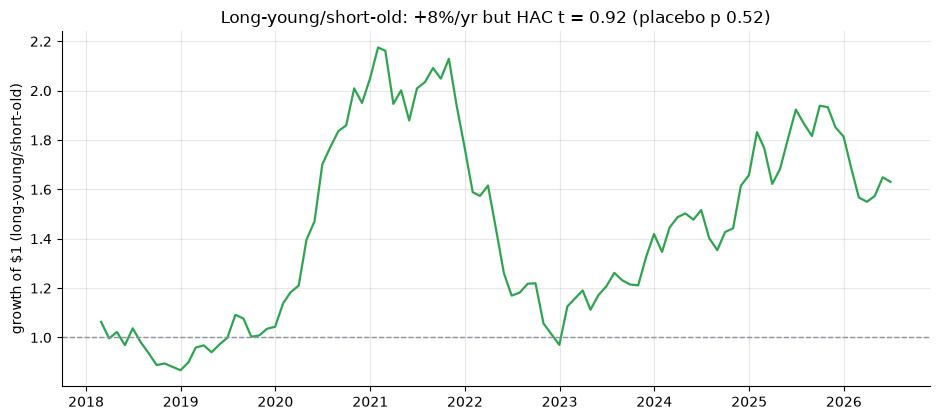

L/S +8.0%/yr | Newey-West HAC t +0.92 (4 lags) | label-shuffle placebo p 0.52


In [2]:
if HAVE_REAL:
    bs = st.bucket_stats(RET); h = bs['ls']['hac']
    pl = st.placebo_pvalue(PX, data, n_perm=2000)
    ls_ann = bs['ls']['ann_ret']*100; t = h['t']; p = pl['p']; lags = h['lags']
else:
    ls_ann, t, p, lags = 7.97, 0.92, 0.523, 4
if HAVE_REAL:
    cum = (1+RET['ls']).cumprod()
    fig, ax = plt.subplots(figsize=(9.5, 4.3))
    ax.plot(cum.index, cum.values, c=GREEN, lw=1.6)
    ax.axhline(1, c=GREY, ls='--', lw=1)
    ax.set_ylabel('growth of $1 (long-young/short-old)')
    ax.set_title(f'Long-young/short-old: +{ls_ann:.0f}%/yr but HAC t = {t:.2f} (placebo p {p:.2f})')
    plt.tight_layout(); plt.show()
print(f'L/S {ls_ann:+.1f}%/yr | Newey-West HAC t {t:+.2f} ({lags} lags) | label-shuffle placebo p {p:.2f}')

> 💡 In plain words: H₁ **not rejected.** +8%/yr looks like a lot, but the HAC *t* is only 0.92 — well short of 2 — and a *random* young/old relabelling of the same CEOs produces a |t| this big **52% of the time**. No reliable premium on the tape.

### 4b · Alpha vs beta — H₂ (the decisive control)

Regress the L/S on the market. If the 'young premium' is just a high-beta growth tilt, the **intercept (alpha)** collapses even while the raw spread looks big.

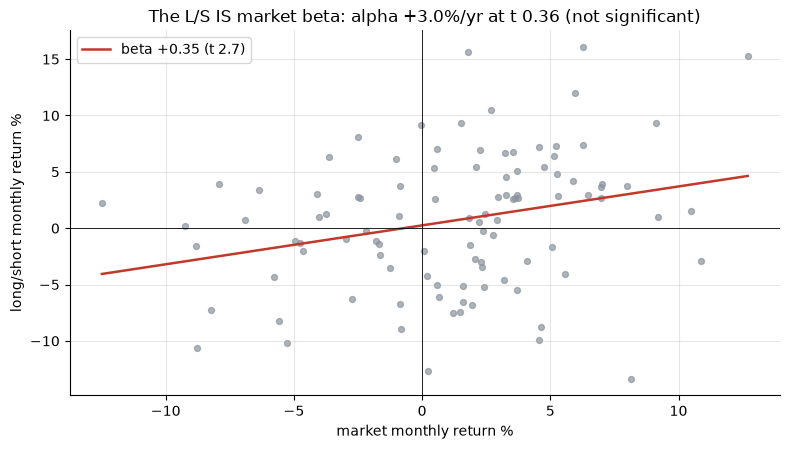

CAPM: alpha +2.98%/yr (t +0.36) | market beta +0.35 (t +2.7) | R2 0.07


In [3]:
if HAVE_REAL:
    ca = st.capm_alpha(RET['ls'].to_numpy(), RET['mkt'].to_numpy())
    a_ann = ca['alpha']*12*100; a_t = ca['alpha_t']; beta = ca['beta']; b_t = ca['beta_t']; r2 = ca['r2']
    x = RET['mkt'].to_numpy()*100; y = RET['ls'].to_numpy()*100
else:
    a_ann, a_t, beta, b_t, r2 = 2.98, 0.36, 0.35, 2.7, 0.07
    rng = np.random.default_rng(0); x = rng.normal(0,4,101); y = beta*x + rng.normal(0,5,101)
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, s=18, c=GREY, alpha=.7)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, a_ann/12 + beta*xs, c=RED, lw=1.8, label=f'beta {beta:+.2f} (t {b_t:.1f})')
ax.axhline(0, c='k', lw=.6); ax.axvline(0, c='k', lw=.6)
ax.set_xlabel('market monthly return %'); ax.set_ylabel('long/short monthly return %')
ax.legend(); ax.set_title(f'The L/S IS market beta: alpha {a_ann:+.1f}%/yr at t {a_t:.2f} (not significant)')
plt.tight_layout(); plt.show()
print(f'CAPM: alpha {a_ann:+.2f}%/yr (t {a_t:+.2f}) | market beta {beta:+.2f} (t {b_t:+.1f}) | R2 {r2:.2f}')

> 💡 In plain words: H₂ **decisively not rejected.** The book carries a real market beta (**+0.35**, *t* = 2.7) — it goes up when the market does — but the **alpha is +3.0%/yr at *t* = 0.36**, indistinguishable from zero. The entire 'young-CEO premium' is the market exposure. There is no age alpha.

### 4c · Robustness — H₃ (cutoff & regime)

A real effect is stable. This one's *t* wanders with the arbitrary age line, and its *sign* flips with the macro regime.

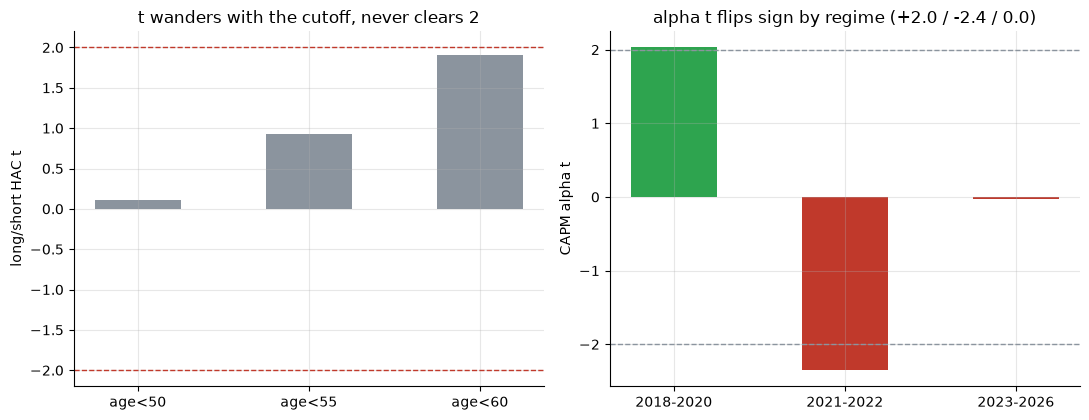

cutoff t: {'age<50': 0.1, 'age<55': 0.92, 'age<60': 1.9}
regime alpha t: {'2018-2020': 2.03, '2021-2022': -2.35, '2023-2026': -0.03}


In [4]:
cut = [('age<50', 1.1, 0.105, -0.657, 0.496), ('age<55', 8.0, 0.924, 0.361, 0.345), ('age<60', 11.0, 1.901, 1.461, 0.238)]
sub = [('2018-2020', 26.6, 1.961, 2.029, 0.124), ('2021-2022', -34.5, -2.222, -2.353, 0.176), ('2023-2026', 16.8, 1.643, -0.035, 0.806)]
if HAVE_REAL:
    cs = st.cutoff_sweep(data, PX, [50,55,60])
    clabs = list(cs.index); cts = cs['ls_t'].tolist()
    splits=[('2018-2020','2018-01-01','2020-12-31'),('2021-2022','2021-01-01','2022-12-31'),('2023-2026','2023-01-01','2026-06-30')]
    sp = st.subperiod_sweep(RET, splits); slabs=list(sp.index); sats=sp['alpha_t'].tolist()
else:
    clabs=[c[0] for c in cut]; cts=[c[2] for c in cut]
    slabs=[s[0] for s in sub]; sats=[s[3] for s in sub]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.3))
a1.bar(clabs, cts, color=GREY, width=.5); a1.axhline(2,c=RED,ls='--',lw=1); a1.axhline(-2,c=RED,ls='--',lw=1)
a1.set_ylabel('long/short HAC t'); a1.set_title('t wanders with the cutoff, never clears 2')
cols=[GREEN if v>0 else RED for v in sats]
a2.bar(slabs, sats, color=cols, width=.5); a2.axhline(2,c=GREY,ls='--',lw=1); a2.axhline(-2,c=GREY,ls='--',lw=1)
a2.set_ylabel('CAPM alpha t'); a2.set_title('alpha t flips sign by regime (+2.0 / -2.4 / 0.0)')
plt.tight_layout(); plt.show()
print('cutoff t:', dict(zip(clabs,[round(t,2) for t in cts])))
print('regime alpha t:', dict(zip(slabs,[round(t,2) for t in sats])))

> 💡 In plain words: H₃ **rejected.** Slide the 'young' line and the *t* runs 0.1 → 0.9 → 1.9 (never significant). Split by era and the alpha *t* is +2.0 (2018-20 growth boom), −2.4 (2021-22 rate shock), ≈0 (2023-26). A single sign that reverses with interest rates is the signature of a **factor exposure**, not a CEO-age premium.

## 5 · The verdict

- **Signal `NONE`** — H₁ not rejected (HAC *t* 0.92, placebo *p* 0.52); capped below `REAL` by construction (curated, confounded, not survivorship-free).
- **Tradability `MIRAGE`** — CAPM alpha +3.0%/yr at *t* 0.36; the +7%/yr net spread is market/growth beta you can rent cheaper.
- **Young-CEO edge? `MISATTRIBUTED`** — young Sharpe 0.90 < old 1.08; the gap is sector/size/vintage, and its sign flips by regime.

## 6 · Could you trade it? — costs and the borrow

Turnover is negligible (age is nearly static), so frictions barely dent it — which only underlines that there is nothing real to charge them against.

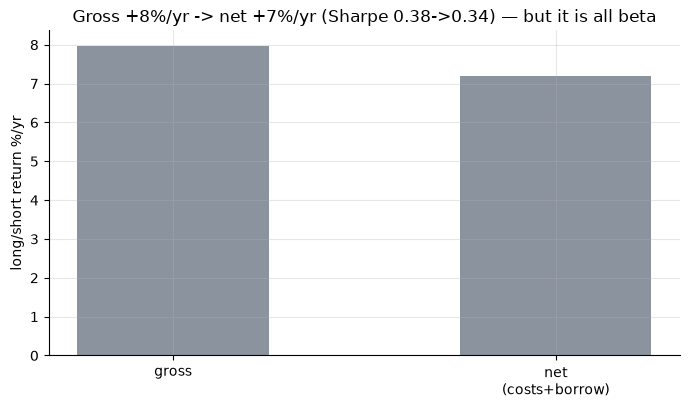

gross +8.0%/yr (Sharpe 0.38) -> net +7.2%/yr (Sharpe 0.34); 5bps/leg x 0.30 turnover + 75bps borrow


In [5]:
if HAVE_REAL:
    nc = st.net_of_costs(RET, cost_bps=5.0, borrow_ann_bps=75.0, annual_turnover=0.30)
    gross, net = nc['gross_ann']*100, nc['net_ann']*100
    gsh, nsh = nc['gross_sharpe'], nc['net_sharpe']
else:
    gross, net, gsh, nsh = 7.97, 7.19, 0.38, 0.34
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[GREY, GREY], width=.5)
ax.set_ylabel('long/short return %/yr')
ax.set_title(f'Gross +{gross:.0f}%/yr -> net +{net:.0f}%/yr (Sharpe {gsh:.2f}->{nsh:.2f}) — but it is all beta')
plt.tight_layout(); plt.show()
print(f'gross +{gross:.1f}%/yr (Sharpe {gsh:.2f}) -> net +{net:.1f}%/yr (Sharpe {nsh:.2f}); 5bps/leg x 0.30 turnover + 75bps borrow')

> 💡 In plain words: net still ~7%/yr, but its Sharpe (~0.34) is *entirely* the market beta — a growth ETF gives you the same exposure without a short-borrow. There is no age-specific residual to harvest. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or would it print alpha-*t* ≈ 0 no matter what? Build a synthetic world where young firms carry BOTH a higher beta (like the real one) AND a genuine planted `age_alpha`. The CAPM alpha *t* must stay flat at the null (beta tilt only) and rise sharply once a real premium is planted — averaged over 25 seeds so no single lucky seed fakes it.

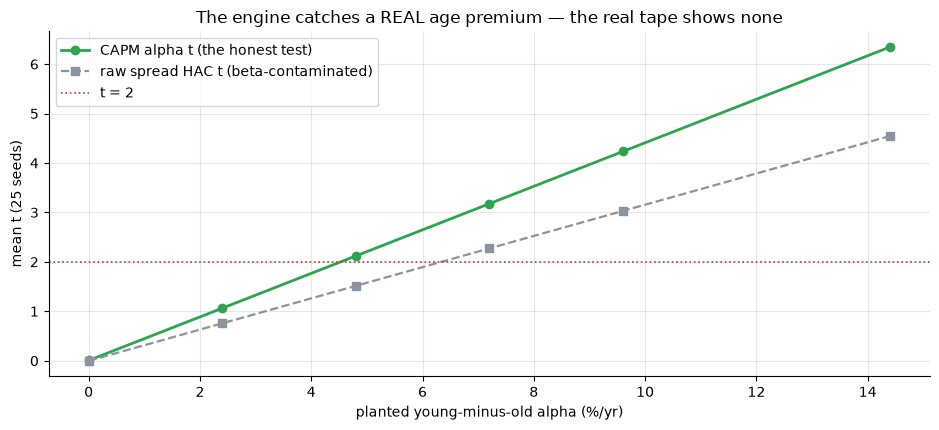

age_alpha  +0.0%/yr -> mean alpha t +0.01, mean raw t -0.00
age_alpha  +2.4%/yr -> mean alpha t +1.06, mean raw t +0.76
age_alpha  +4.8%/yr -> mean alpha t +2.12, mean raw t +1.51
age_alpha  +7.2%/yr -> mean alpha t +3.18, mean raw t +2.27
age_alpha  +9.6%/yr -> mean alpha t +4.23, mean raw t +3.03
age_alpha +14.4%/yr -> mean alpha t +6.35, mean raw t +4.54


In [6]:
ctrl = [(0.0, 0.01, -0.0), (0.004, 2.12, 1.51), (0.008, 4.23, 3.03), (0.012, 6.35, 4.54)]
alphas = [0.0, 0.002, 0.004, 0.006, 0.008, 0.012]
res = [st.synthetic_mean_alpha_t(data, age_alpha=a, n_seeds=25) for a in alphas]
at = [r['mean_alpha_t'] for r in res]; rt = [r['mean_raw_t'] for r in res]
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot([a*12*100 for a in alphas], at, 'o-', c=GREEN, lw=2, label='CAPM alpha t (the honest test)')
ax.plot([a*12*100 for a in alphas], rt, 's--', c=GREY, lw=1.6, label='raw spread HAC t (beta-contaminated)')
ax.axhline(2, c=RED, ls=':', lw=1.2, label='t = 2')
ax.set_xlabel('planted young-minus-old alpha (%/yr)'); ax.set_ylabel('mean t (25 seeds)')
ax.legend(); ax.set_title('The engine catches a REAL age premium — the real tape shows none')
plt.tight_layout(); plt.show()
for a, r in zip(alphas, res): print(f'age_alpha {a*12*100:+5.1f}%/yr -> mean alpha t {r["mean_alpha_t"]:+.2f}, mean raw t {r["mean_raw_t"]:+.2f}')

At the null (`age_alpha = 0`) the CAPM alpha *t* sits at ~0 — no false signal, even though young firms carry a higher beta (the raw *t* is noisy but the alpha is clean). Plant a real premium and the alpha *t* sails past 2. So the engine is a faithful detector, and the flat real-tape alpha (*t* = 0.36) is a statement about **the world**: a CEO's age carries no return alpha on this tape, and a curated ~40-name growth-tilted table could never certify one if it did. For the sibling C-suite folklore, see [543 Western-Zodiac-CEO](../../543-western-zodiac-ceo/) and [391 CEO-Turnover](../../391-ceo-turnover/).